# Predict Bike Sharing Demand with AutoGluon Template

## Project: Predict Bike Sharing Demand with AutoGluon
This notebook is a template with each step that you need to complete for the project.

Please fill in your code where there are explicit `?` markers in the notebook. You are welcome to add more cells and code as you see fit.

Once you have completed all the code implementations, please export your notebook as a HTML file so the reviews can view your code. Make sure you have all outputs correctly outputted.

`File-> Export Notebook As... -> Export Notebook as HTML`

There is a writeup to complete as well after all code implememtation is done. Please answer all questions and attach the necessary tables and charts. You can complete the writeup in either markdown or PDF.

Completing the code template and writeup template will cover all of the rubric points for this project.

The rubric contains "Stand Out Suggestions" for enhancing the project beyond the minimum requirements. The stand out suggestions are optional. If you decide to pursue the "stand out suggestions", you can include the code in this notebook and also discuss the results in the writeup file.

## Step 1: Create an account with Kaggle

### Create a Kaggle account and generate an API token

Follow the steps below to generate a Kaggle API token for your account. Each student should create and use their own token. Do not share your token or commit it to Git.

1. Go to Kaggle and click your profile icon in the upper-right corner.

![Kaggle profile icon](./img/kaggle-api-key-1.png)

2. In the account menu, select **Your API tokens**.

![Kaggle account menu with Your API tokens](./img/kaggle-api-key-2.png)

3. On the **API Tokens** tab, click **Generate New Token**.

![Kaggle API Tokens tab](./img/kaggle-api-key-3.png)

4. Enter a token name, such as `bike-sharing-demand`, and click **Generate**.

![Generate a new Kaggle API token](./img/kaggle-api-key-4.png)

5. Keep the generated API token window open. You will need to copy this token and paste it into the `KAGGLE_API_TOKEN` prompt in the next step. You will not be able to view the token again after closing this window.

![Generated Kaggle API token](./img/kaggle-api-key-5.png)

## Step 2: Download the Kaggle dataset using the kaggle python library

### Open up Sagemaker Studio and use starter template

1. Notebook should be using a `ml.t3.medium` instance (2 vCPU + 4 GiB)
2. Notebook should be using kernal: `Python 3 (MXNet 1.8 Python 3.7 CPU Optimized)`

### Install packages

If you see dependency conflict messages after running the following installation cell, you can usually ignore them as long as `autogluon.tabular` and `kaggle` import successfully in the next cell. This project uses AutoGluon Tabular only.

In [7]:
!pip install -U pip setuptools wheel
!pip install -U autogluon.tabular kaggle --no-cache-dir
# !pip install -U kaggle --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 251.0 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 21.0.0
    Uninstalling pyarrow-21.0.0:
      Successfully uninstalled pyarrow-21.0.0━━━ 0/8 [pyarrow]
  Attempting uninstall: autogluon.common━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/8 [jupytext]]
    Found existing installation: autogluon.common 1.5.0━━━━━━━ 2/8 [jupytext]
    Uninstalling autogluon.common-1.5.0:━━━━━━━━━━━━━━━━━━━━━━ 2/8 [jupytext]
      Successfully uninstalled autogluon.common-1.5.0━━━━━━━━━━━━━ 3/8 [autogluon.common]
  Attempting uninstall: autogluon.features━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [autogluon.common]
    Found existing installation: autogluon.features 1.5.0━━━━━ 3/8 [autogluon.common]
    Uninstalling autogluon.features-1.5.0:━━━━━━━━━━━━━━━━━━━━ 3/8 [autogluon.common]
      Successfully uninstalled autogluon.features-1.5.0━━━━━━━━━━━ 5/8 [autogluon.features]
  Attempting uninstall: autogluon.core╺━━━━━━━━━━━━━━ 5/8 [autog

### Setup Kaggle API Key

In [3]:
# # create the .kaggle directory and an empty kaggle.json file
# !mkdir -p $HOME/.kaggle
# !touch $HOME/.kaggle/kaggle.json
# !chmod 600 $HOME/.kaggle/kaggle.json

In [ ]:
# from getpass import getpass
# from pathlib import Path
# import os

# # Prompt for the Kaggle API token instead of hard-coding it in the notebook.
# kaggle_api_token = getpass("Paste your Kaggle API token: ").strip()

# if not kaggle_api_token:
#     raise ValueError("Kaggle API token cannot be empty.")

# # Store the token in the default location used by the Kaggle CLI.
# access_token_path = Path.home() / ".kaggle" / "access_token"
# access_token_path.parent.mkdir(parents=True, exist_ok=True)
# access_token_path.write_text(kaggle_api_token)
# access_token_path.chmod(0o600)

# # Make the token available to commands run in this notebook session.
# os.environ["KAGGLE_API_TOKEN"] = kaggle_api_token

### Join the Bike Sharing Demand competition

Before downloading the dataset, you must join the Kaggle competition and accept the competition rules.

1. Open the [Bike Sharing Demand competition](https://www.kaggle.com/c/bike-sharing-demand) page, go to the **Data** tab, and click **Join the competition**.

![Join the Bike Sharing Demand competition](./img/kaggle-join-competition.png)

2. Review the competition terms and conditions, then click **I Understand and Accept**.

![Accept the Bike Sharing Demand competition rules](./img/kaggle-accept-competition-rules.png)

### Download and explore dataset

In [9]:
# Download the Bike Sharing Demand dataset as a zip file.
# If the file already exists, -o overwrites it.
!kaggle competitions download -c bike-sharing-demand -o

# Unzip the downloaded dataset files.
!unzip -o bike-sharing-demand.zip

100%|███████████████████████████████████████| 189k/189k [00:00<00:00, 30.0MB/s]

Archive:  bike-sharing-demand.zip
  inflating: sampleSubmission.csv    
  inflating: test.csv                
  inflating: train.csv               


In [10]:
import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor

In [11]:
# Create the train dataset in pandas by reading the csv
# Set the parsing of the datetime column so you can use some of the `dt` features in pandas later
train = pd.read_csv("train.csv")
train["datetime"] = pd.to_datetime(train["datetime"])
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [13]:
# Simple output of the train dataset to view some of the min/max/varition of the dataset features.
train.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


In [14]:
# Create the test pandas dataframe in pandas by reading the csv, remember to parse the datetime!
test = pd.read_csv("test.csv")
test["datetime"] = pd.to_datetime(test["datetime"])
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [15]:
# Same thing as train and test dataset
submission = pd.read_csv("sampleSubmission.csv")
submission["datetime"] = pd.to_datetime(submission["datetime"])
submission.head()

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


## Step 3: Train a model using AutoGluon’s Tabular Prediction

Requirements:
* We are predicting `count`, so it is the label we are setting.
* Ignore `casual` and `registered` columns as they are also not present in the test dataset. 
* Use the `root_mean_squared_error` as the metric to use for evaluation.
* Set a time limit of 10 minutes (600 seconds).
* Use the preset `best_quality` to focus on creating the best model.

In [16]:
# predictor = TabularPredictor(label="count", eval_metric="root_mean_squared_error", learner_kwargs={"ignored_columns": ["casual", "registered"]}).fit(train, time_limit=600, presets="medium_quality")  # ml.t3.medium's resources not enough for presets="best_quality"
predictor = TabularPredictor.load("/home/sagemaker-user/aws-ml-engineer-nanodegree/project-1-bike-sharing-demand/AutogluonModels/ag-20260924_085453", require_version_match=False)

### Review AutoGluon's training run with ranking of models that did the best.

In [17]:
predictor.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                 model   score_val              eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      RandomForestMSE -122.012844  root_mean_squared_error       0.148014   12.455482                0.148014          12.455482            1       True          3
1  WeightedEnsemble_L2 -122.012844  root_mean_squared_error       0.148464   12.469724                0.000450           0.014242            2       True          9
2        ExtraTreesMSE -128.429416  root_mean_squared_error       0.129033    6.292614                0.129033           6.292614            1       True          5
3        LightGBMLarge -130.528829  root_mean_squared_error       0.043645    1.543281                0.043645           1.543281            1       True          8
4             LightGBM -134.080427  root_mean_squared_error       0.033398    0.845886                0.033398   

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestMSE': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesMSE': 'XTModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': -135.95803375936984,
  'LightGBM': -134.0804268849742,
  'RandomForestMSE': -122.01284447953923,
  'CatBoost': -134.23616330181272,
  'ExtraTreesMSE': -128.42941608551303,
  'XGBoost': -135.7689524728067,
  'NeuralNetTorch': -139.2237924860225,
  'LightGBMLarge': -130.52882934609937,
  'WeightedEnsemble_L2': -122.01284447953923},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestMSE': ['RandomForestMSE'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  'XGBoost': ['XGBoost'],
  'NeuralNetTorch': ['NeuralNetTorch'],
  'LightGBMLarge': ['

<Axes: xlabel='model'>

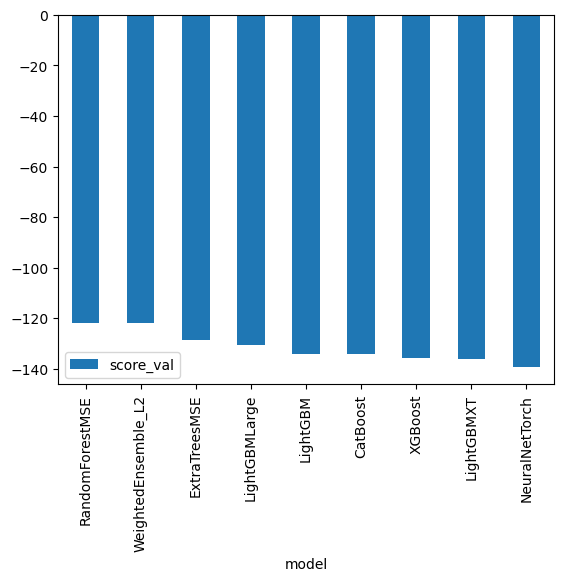

In [18]:
predictor.leaderboard(silent=True).plot(kind="bar", x="model", y="score_val")

### Create predictions from test dataset

In [19]:
predictions = predictor.predict(test)
predictions.head()

0    90.313332
1    86.563332
2    86.563332
3    91.083336
4    91.083336
Name: count, dtype: float32

#### NOTE: Kaggle will reject the submission if we don't set everything to be > 0.

In [20]:
# Describe the `predictions` series to see if there are any negative values
predictions.describe()

count    6493.000000
mean      218.449448
std       126.180077
min        16.426666
25%       120.066666
50%       193.473328
75%       293.656677
max       631.893311
Name: count, dtype: float64

In [21]:
# How many negative values do we have?
(predictions < 0).sum()

0

In [22]:
# Set them to zero
predictions[predictions < 0] = 0

### Set predictions to submission dataframe, save, and submit

In [23]:
submission["count"] = predictions
submission.to_csv("submission.csv", index=False)

In [24]:
# !kaggle competitions submit -c bike-sharing-demand -f submission.csv -m "first raw submission"

#### View submission via the command line or in the web browser under the competition's page - `My Submissions`

In [25]:
!kaggle competitions submissions -c bike-sharing-demand | tail -n +1 | head -n 6

     ref  fileName                     date                        description           status                     publicScore  privateScore  
--------  ---------------------------  --------------------------  --------------------  -------------------------  -----------  ------------  
56520184  submission_new_features.csv  2026-09-24 11:36:44.097000  new features          SubmissionStatus.COMPLETE  0.55333      0.55333       
56518121  submission.csv               2026-09-24 09:45:42.553000  first raw submission  SubmissionStatus.COMPLETE  1.41883      1.41883       


#### Initial score of `1.41883`

## Step 4: Exploratory Data Analysis and Creating an additional feature
* Any additional feature will do, but a great suggestion would be to separate out the datetime into hour, day, or month parts.

In [26]:
features = [
    col for col in train.columns 
    if col not in ["casual", "registered", "count"]
]
features

['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed']

array([[<Axes: title={'center': 'datetime'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'holiday'}>],
       [<Axes: title={'center': 'workingday'}>,
        <Axes: title={'center': 'weather'}>,
        <Axes: title={'center': 'temp'}>],
       [<Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'windspeed'}>]], dtype=object)

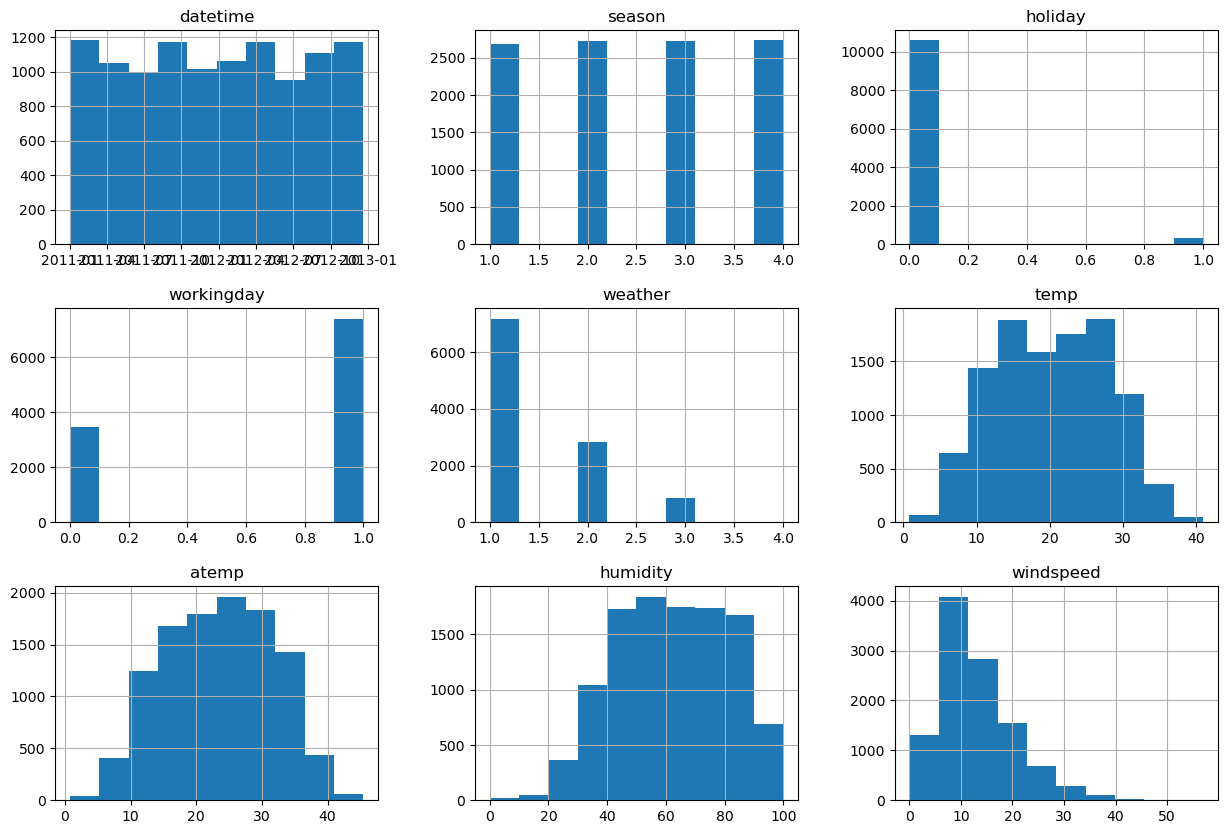

In [27]:
# Create a histogram of all features to show the distribution of each one relative to the data. This is part of the exploritory data analysis
train[features].hist(figsize=(15, 10))

In [28]:
# create a new feature
train["month"] = train.datetime.dt.month
test["month"] = test.datetime.dt.month

train["day"] = train.datetime.dt.day
test["day"] = test.datetime.dt.day

train["hour"] = train.datetime.dt.hour
test["hour"] = test.datetime.dt.hour

## Make category types for these so models know they are not just numbers
* AutoGluon originally sees these as ints, but in reality they are int representations of a category.
* Setting the dtype to category will classify these as categories in AutoGluon.

In [29]:
train["season"] = train["season"].astype("category")
train["weather"] = train["weather"].astype("category")
test["season"] = train["season"].astype("category")
test["weather"] = train["weather"].astype("category")

In [30]:
# View our new feature
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,1,4


In [31]:
# Verify the dtypes
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  month       10886 non-null  int32         
 13  day         10886 non-null  int32         
 14  hour        10886 non-null  int32         
dtypes: category(2), datetime64[ns](1), float64(3), int32(3), int64(6)
memo

In [32]:
features = [
    col for col in train.columns 
    if col not in ["casual", "registered", "count"]
]
features

['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'month',
 'day',
 'hour']

array([[<Axes: title={'center': 'datetime'}>,
        <Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'workingday'}>],
       [<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'humidity'}>],
       [<Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'hour'}>, <Axes: >, <Axes: >]],
      dtype=object)

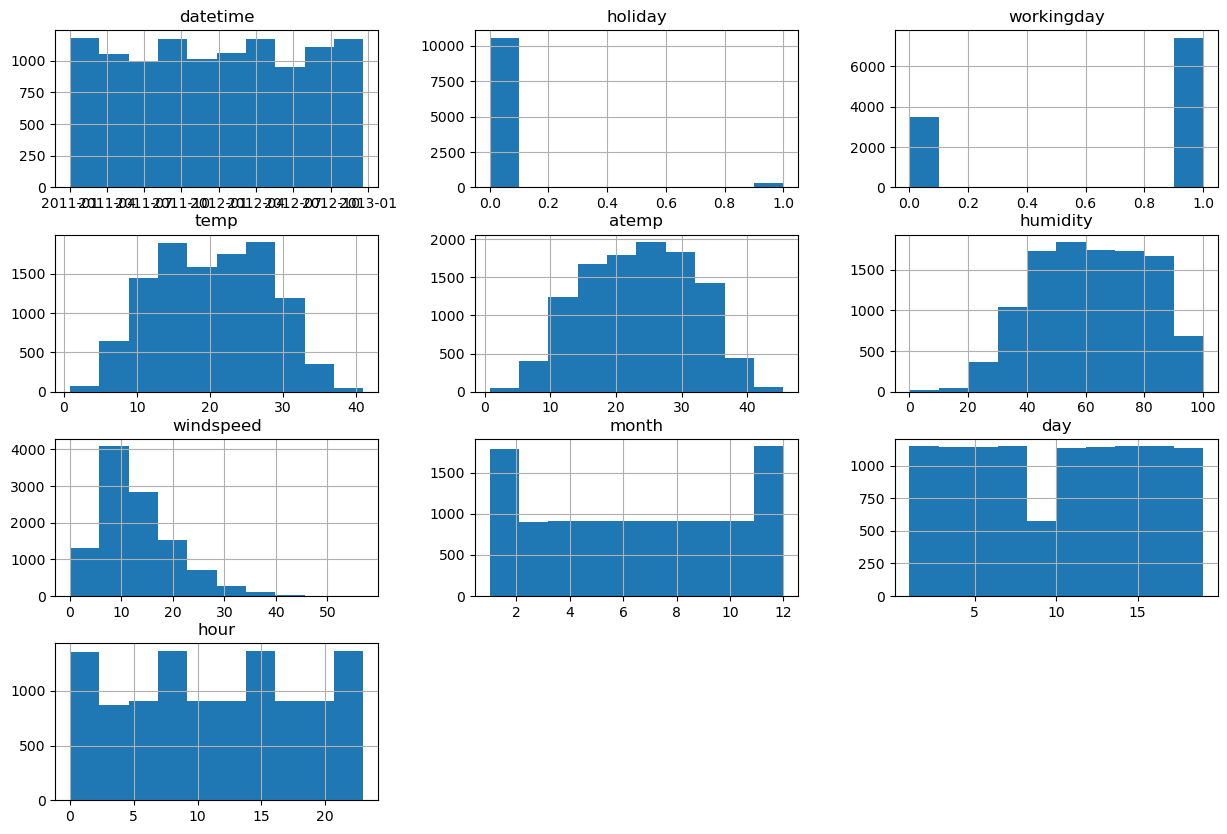

In [33]:
# View histogram of all features again now with the hour feature
train[features].hist(figsize=(15, 10))

## Step 5: Rerun the model with the same settings as before, just with more features

In [34]:
# predictor_new_features = TabularPredictor.load("/home/sagemaker-user/aws-ml-engineer-nanodegree/project-1-bike-sharing-demand/AutogluonModels/ag-20260924_100951")
predictor_new_features = TabularPredictor(label="count", eval_metric="root_mean_squared_error", learner_kwargs={"ignored_columns": ["casual", "registered"]}).fit(train, time_limit=600, presets="medium_quality")  # ml.t3.medium's resources not enough for presets="best_quality"

No path specified. Models will be saved in: "AutogluonModels/ag-20260925_123355"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Tue Aug 25 15:42:53 UTC 2026
CPU Count:          2
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
Memory Avail:       4.69 GB / 7.64 GB (61.4%)
Disk Space Avail:   27.00 GB / 29.94 GB (90.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/home/sagemaker-user/aws-ml-engineer-nanodegree/project-1-bike-sharing-demand/AutogluonModels/ag-20260925_123355"
Train Data Rows:    10886
Train Data Columns: 14
Label Column:       count
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == int and many un

[1000]	valid_set's rmse: 38.2491
[2000]	valid_set's rmse: 36.5149
[3000]	valid_set's rmse: 36.1803
[4000]	valid_set's rmse: 36.0999
[5000]	valid_set's rmse: 36.0693
[6000]	valid_set's rmse: 36.1261


	-36.0589	 = Validation score   (-root_mean_squared_error)
	6.29s	 = Training   runtime
	0.7s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 592.29s of the 592.29s of remaining time.
	Fitting with cpus=1, gpus=0, mem=0.0/4.6 GB


[1000]	valid_set's rmse: 35.2001


	-35.1312	 = Validation score   (-root_mean_squared_error)
	1.49s	 = Training   runtime
	0.11s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 590.58s of the 590.58s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.0/4.6 GB
	-38.6224	 = Validation score   (-root_mean_squared_error)
	13.97s	 = Training   runtime
	0.15s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 575.48s of the 575.48s of remaining time.
	Fitting with cpus=1, gpus=0
	-35.0673	 = Validation score   (-root_mean_squared_error)
	166.35s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 409.07s of the 409.06s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.0/4.5 GB
	-39.9944	 = Validation score   (-root_mean_squared_error)
	7.01s	 = Training   runtime
	0.14s	 = Validation runtime
Fitting model: NeuralNetFastAI ... Training model for up to 400.82s of the 400.82s of remaining time.
	Fitting wi

[1000]	valid_set's rmse: 33.6416


	-33.597	 = Validation score   (-root_mean_squared_error)
	2.48s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 253.51s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/4.4 GB
	Ensemble Weights: {'LightGBMLarge': 0.417, 'NeuralNetTorch': 0.25, 'XGBoost': 0.167, 'CatBoost': 0.125, 'LightGBM': 0.042}
	-32.3444	 = Validation score   (-root_mean_squared_error)
	0.02s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 346.53s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 3540.6 rows/s (1089 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/sagemaker-user/aws-ml-engineer-nanodegree/project-1-bike-sharing-demand/AutogluonModels/ag-20260925_123355")


In [35]:
predictor_new_features.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                 model  score_val              eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2 -32.344383  root_mean_squared_error       0.307573  313.815307                0.000468           0.016618            2       True          9
1        LightGBMLarge -33.596964  root_mean_squared_error       0.115754    2.483160                0.115754           2.483160            1       True          8
2             CatBoost -35.067345  root_mean_squared_error       0.021657  166.350656                0.021657         166.350656            1       True          4
3             LightGBM -35.131237  root_mean_squared_error       0.109020    1.494838                0.109020           1.494838            1       True          2
4              XGBoost -35.248839  root_mean_squared_error       0.048099    1.958540                0.048099         

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestMSE': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesMSE': 'XTModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': -36.05887466827782,
  'LightGBM': -35.13123727917639,
  'RandomForestMSE': -38.62238841163423,
  'CatBoost': -35.06734532640029,
  'ExtraTreesMSE': -39.994427504102624,
  'XGBoost': -35.24883915306798,
  'NeuralNetTorch': -36.89322144728994,
  'LightGBMLarge': -33.596964122643506,
  'WeightedEnsemble_L2': -32.34438327642457},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT'],
  'LightGBM': ['LightGBM'],
  'RandomForestMSE': ['RandomForestMSE'],
  'CatBoost': ['CatBoost'],
  'ExtraTreesMSE': ['ExtraTreesMSE'],
  'XGBoost': ['XGBoost'],
  'NeuralNetTorch': ['NeuralNetTorch'],
  'LightGBMLarge': ['Ligh

<Axes: xlabel='model'>

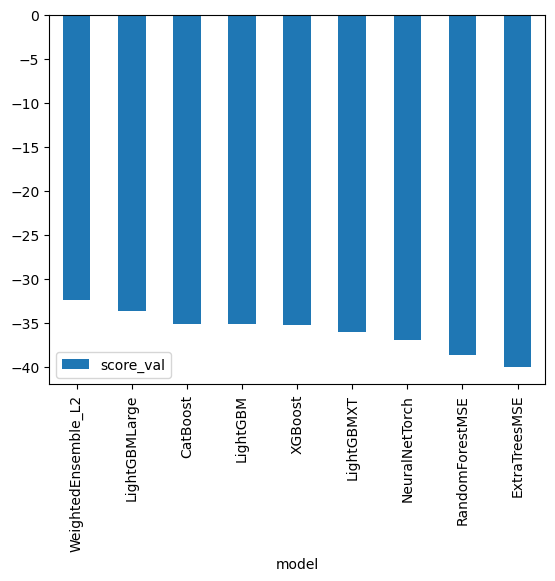

In [36]:
predictor_new_features.leaderboard(silent=True).plot(kind="bar", x="model", y="score_val")

In [37]:
predictor_new_features.model_info("WeightedEnsemble_L2")

{'name': 'WeightedEnsemble_L2',
 'model_type': 'WeightedEnsembleModel',
 'problem_type': 'regression',
 'eval_metric': 'root_mean_squared_error',
 'stopping_metric': 'root_mean_squared_error',
 'fit_time': 0.01661825180053711,
 'num_classes': None,
 'quantile_levels': None,
 'predict_time': 0.00046753883361816406,
 'val_score': -32.34438327642457,
 'hyperparameters': {'use_orig_features': False,
  'valid_stacker': True,
  'max_base_models': 0,
  'max_base_models_per_type': 'auto',
  'save_bag_folds': True,
  'stratify': 'auto',
  'bin': 'auto',
  'n_bins': None,
  'vary_seed_across_folds': False,
  'model_random_seed': 0},
 'hyperparameters_user': {'save_bag_folds': True},
 'hyperparameters_fit': {},
 'hyperparameters_nondefault': ['save_bag_folds'],
 'ag_args_fit': {'max_memory_usage_ratio': 1.0,
  'max_time_limit_ratio': 1.0,
  'max_time_limit': None,
  'min_time_limit': 0,
  'valid_raw_types': None,
  'valid_special_types': None,
  'ignored_type_group_special': None,
  'ignored_type

In [38]:
# Predictions with new model
predictions_with_new_model = predictor_new_features.predict(test)

In [39]:
# How many negative values do we have?
(predictions_with_new_model < 0).sum()

78

In [40]:
# Remember to set all negative values to zero
predictions_with_new_model[predictions_with_new_model < 0] = 0

In [41]:
# Same submitting predictions
submission_new_features = pd.read_csv("sampleSubmission.csv")
submission_new_features["datetime"] = pd.to_datetime(submission["datetime"])
submission_new_features["count"] = predictions_with_new_model
submission_new_features.to_csv("submission_new_features.csv", index=False)

In [42]:
!kaggle competitions submit -c bike-sharing-demand -f submission_new_features.csv -m "new features"

100%|████████████████████████████████████████| 188k/188k [00:00<00:00, 683kB/s]
99 submissions remaining today.
Successfully submitted to Bike Sharing Demand

In [43]:
!kaggle competitions submissions -c bike-sharing-demand | tail -n +1 | head -n 6

     ref  fileName                     date                        description           status                     publicScore  privateScore  
--------  ---------------------------  --------------------------  --------------------  -------------------------  -----------  ------------  
56550672  submission_new_features.csv  2026-09-25 12:40:27.790000  new features          SubmissionStatus.COMPLETE  0.53507      0.53507       
56520184  submission_new_features.csv  2026-09-24 11:36:44.097000  new features          SubmissionStatus.COMPLETE  0.55333      0.55333       
56518121  submission.csv               2026-09-24 09:45:42.553000  first raw submission  SubmissionStatus.COMPLETE  1.41883      1.41883       


#### New Score of `0.53507`

## Step 6: Hyper parameter optimization
* There are many options for hyper parameter optimization.
* Options are to change the AutoGluon higher level parameters or the individual model hyperparameters.
* The hyperparameters of the models themselves that are in AutoGluon. Those need the `hyperparameter` and `hyperparameter_tune_kwargs` arguments.

In [44]:
num_bag_folds = 5
num_stack_levels = 1
# hyperparameters = {
#     "GBM": [
#         {},
#         {"num_leaves": 64},
#         {"num_leaves": 256},
#         {"learning_rate": 0.01},
#     ],
#     "XGB": [
#         {},
#         {"max_depth": 6},
#         {"max_depth": 10},
#     ],
#     "CAT": [
#         {}
#     ]
# }

In [45]:
predictor_new_hpo = TabularPredictor(label="count", eval_metric="root_mean_squared_error", learner_kwargs={"ignored_columns": ["casual", "registered"]}).fit(
    train, time_limit=600, num_bag_folds=num_bag_folds, num_stack_levels=num_stack_levels, presets="good_quality")

No path specified. Models will be saved in: "AutogluonModels/ag-20260925_124105"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Tue Aug 25 15:42:53 UTC 2026
CPU Count:          2
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
Memory Avail:       4.32 GB / 7.64 GB (56.5%)
Disk Space Avail:   26.49 GB / 29.94 GB (88.5%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~5x), but runs the risk of an out-of-memory error during model refit 

[1000]	valid_set's rmse: 39.2612
[2000]	valid_set's rmse: 37.4705
[3000]	valid_set's rmse: 36.9987
[4000]	valid_set's rmse: 36.901
[5000]	valid_set's rmse: 36.9691
[1000]	valid_set's rmse: 40.1504
[2000]	valid_set's rmse: 38.2604
[3000]	valid_set's rmse: 37.7136
[4000]	valid_set's rmse: 37.4664
[5000]	valid_set's rmse: 37.378
[6000]	valid_set's rmse: 37.3065
[7000]	valid_set's rmse: 37.298
[8000]	valid_set's rmse: 37.2914
[1000]	valid_set's rmse: 37.6511
[2000]	valid_set's rmse: 35.822
[3000]	valid_set's rmse: 35.4754
[4000]	valid_set's rmse: 35.2963
[5000]	valid_set's rmse: 35.2549
[6000]	valid_set's rmse: 35.2179
[7000]	valid_set's rmse: 35.1964
[8000]	valid_set's rmse: 35.2225
[1000]	valid_set's rmse: 39.0395
[2000]	valid_set's rmse: 36.7949
[3000]	valid_set's rmse: 36.4649
[4000]	valid_set's rmse: 36.3971
[5000]	valid_set's rmse: 36.382
[1000]	valid_set's rmse: 38.4173
[2000]	valid_set's rmse: 36.3398
[3000]	valid_set's rmse: 36.0016
[4000]	valid_set's rmse: 35.7927
[5000]	valid_se

	-36.2775	 = Validation score   (-root_mean_squared_error)
	39.24s	 = Training   runtime
	8.62s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 51.52s of the 101.28s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)


[1000]	valid_set's rmse: 35.608
[1000]	valid_set's rmse: 35.4248
[2000]	valid_set's rmse: 35.3575
[1000]	valid_set's rmse: 35.8638
[2000]	valid_set's rmse: 35.6608
[1000]	valid_set's rmse: 35.2487
[2000]	valid_set's rmse: 34.8527
[1000]	valid_set's rmse: 33.9223


	-34.9866	 = Validation score   (-root_mean_squared_error)
	12.79s	 = Training   runtime
	1.93s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 36.75s of the 86.51s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.0/4.3 GB
	-39.3069	 = Validation score   (-root_mean_squared_error)
	11.27s	 = Training   runtime
	0.5s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 24.79s of the 74.56s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	Ran out of time, early stopping on iteration 635.
	Ran out of time, early stopping on iteration 642.
	Ran out of time, early stopping on iteration 683.
	Ran out of time, early stopping on iteration 766.
	Ran out of time, early stopping on iteration 885.
	-38.4021	 = Validation score   (-root_mean_squared_error)
	23.31s	 = Training   runtime
	

[1000]	valid_set's rmse: 38.6725
[2000]	valid_set's rmse: 36.1333
[3000]	valid_set's rmse: 35.5917
[4000]	valid_set's rmse: 35.408
[5000]	valid_set's rmse: 35.3558
[6000]	valid_set's rmse: 35.3305
[7000]	valid_set's rmse: 35.3203
[8000]	valid_set's rmse: 35.339
[9000]	valid_set's rmse: 35.3776
[1000]	valid_set's rmse: 36.1479
[2000]	valid_set's rmse: 34.2655
[3000]	valid_set's rmse: 33.9182
[4000]	valid_set's rmse: 33.8076
[5000]	valid_set's rmse: 33.775
[6000]	valid_set's rmse: 33.7818
[1000]	valid_set's rmse: 37.4615
[2000]	valid_set's rmse: 35.463
[3000]	valid_set's rmse: 35.0626
[4000]	valid_set's rmse: 34.936
[5000]	valid_set's rmse: 34.8919
[6000]	valid_set's rmse: 34.8548
[7000]	valid_set's rmse: 34.9058
[1000]	valid_set's rmse: 38.0054
[2000]	valid_set's rmse: 35.9931
[3000]	valid_set's rmse: 35.5503
[4000]	valid_set's rmse: 35.3969
[5000]	valid_set's rmse: 35.3656
[6000]	valid_set's rmse: 35.3934
[1000]	valid_set's rmse: 37.4782
[2000]	valid_set's rmse: 35.6145
[3000]	valid_se

	-34.8218	 = Validation score   (-root_mean_squared_error)
	39.48s	 = Training   runtime
	9.11s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 237.47s of the 380.65s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)


[1000]	valid_set's rmse: 34.1495
[2000]	valid_set's rmse: 33.8885
[3000]	valid_set's rmse: 33.8465
[1000]	valid_set's rmse: 32.1366
[2000]	valid_set's rmse: 31.7815
[3000]	valid_set's rmse: 31.676
[4000]	valid_set's rmse: 31.6773
[1000]	valid_set's rmse: 35.1986
[2000]	valid_set's rmse: 34.8006
[1000]	valid_set's rmse: 33.3263
[1000]	valid_set's rmse: 37.0531


	-34.1252	 = Validation score   (-root_mean_squared_error)
	17.38s	 = Training   runtime
	2.47s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 217.58s of the 360.76s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.1/4.0 GB
	-38.7895	 = Validation score   (-root_mean_squared_error)
	12.61s	 = Training   runtime
	0.49s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 204.27s of the 347.45s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=0)
	Ran out of time, early stopping on iteration 3490.
	Ran out of time, early stopping on iteration 3631.
	Ran out of time, early stopping on iteration 3781.
	Ran out of time, early stopping on iteration 4106.
	Ran out of time, early stopping on iteration 4652.
	-33.9186	 = Validation score   (-root_mean_squared_error)
	192.21s	 = Training 

In [46]:
predictor_new_hpo.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                          model  score_val              eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           WeightedEnsemble_L3 -31.942938  root_mean_squared_error      14.132085  396.250583                0.000655           0.038207            3      False         15
1          ExtraTreesMSE_BAG_L2 -32.244309  root_mean_squared_error      13.415308  278.854895                0.492419           7.117428            2      False         12
2           WeightedEnsemble_L2 -32.376759  root_mean_squared_error      12.403487  265.890550                0.000653           0.024813            2      False          7
3               CatBoost_BAG_L2 -32.480578  root_mean_squared_error      12.947195  306.729819                0.024306          34.992352            2      False         11
4               LightGBM_BAG_L2 -32.551572  root_mean_squared_error      

{'model_types': {'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1': 'StackerEnsembleModel_XT',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'LightGBMXT_BAG_L2': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L2': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L2': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L2': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L2': 'StackerEnsembleModel_XT',
  'XGBoost_BAG_L2': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L2': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'WeightedEnsemble_L3': 'WeightedEnsembleModel',
  'LightGBMXT_BAG_L1_FULL': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1_FULL': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1_FULL': 'StackerEnsembleModel_RF',
  'CatBoost_BA

<Axes: xlabel='model'>

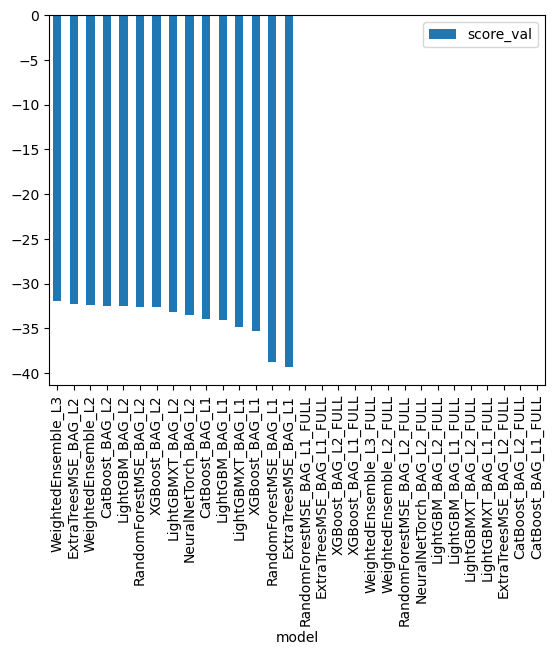

In [47]:
predictor_new_hpo.leaderboard(silent=True).plot(kind="bar", x="model", y="score_val")

In [51]:
predictor_new_hpo.model_info("WeightedEnsemble_L3_FULL")

{'name': 'WeightedEnsemble_L3_FULL',
 'model_type': 'WeightedEnsembleModel',
 'problem_type': 'regression',
 'eval_metric': 'root_mean_squared_error',
 'stopping_metric': 'root_mean_squared_error',
 'fit_time': 0.038207292556762695,
 'num_classes': None,
 'quantile_levels': None,
 'predict_time': None,
 'val_score': None,
 'hyperparameters': {'use_orig_features': False,
  'valid_stacker': True,
  'max_base_models': 0,
  'max_base_models_per_type': 'auto',
  'save_bag_folds': True,
  'stratify': 'auto',
  'bin': 'auto',
  'n_bins': None,
  'vary_seed_across_folds': False,
  'model_random_seed': 0},
 'hyperparameters_user': {'save_bag_folds': False},
 'hyperparameters_fit': {},
 'hyperparameters_nondefault': ['save_bag_folds'],
 'ag_args_fit': {'max_memory_usage_ratio': 1.0,
  'max_time_limit_ratio': 1.0,
  'max_time_limit': None,
  'min_time_limit': 0,
  'valid_raw_types': None,
  'valid_special_types': None,
  'ignored_type_group_special': None,
  'ignored_type_group_raw': None,
  'get

In [50]:
# Predictions with new model
predictions_with_new_hpo_model = predictor_new_hpo.predict(test)

In [52]:
# How many negative values do we have?
(predictions_with_new_hpo_model < 0).sum()

3

In [53]:
# Remember to set all negative values to zero
predictions_with_new_hpo_model[predictions_with_new_hpo_model < 0] = 0

In [55]:
# Same submitting predictions
submission_new_hpo = pd.read_csv("sampleSubmission.csv")
submission_new_hpo["datetime"] = pd.to_datetime(submission["datetime"])
submission_new_hpo["count"] = predictions_with_new_hpo_model
submission_new_hpo.to_csv("submission_new_hpo.csv", index=False)

In [56]:
!kaggle competitions submit -c bike-sharing-demand -f submission_new_hpo.csv -m "new features with hyperparameters"

100%|████████████████████████████████████████| 188k/188k [00:00<00:00, 703kB/s]
98 submissions remaining today.
Successfully submitted to Bike Sharing Demand

In [57]:
!kaggle competitions submissions -c bike-sharing-demand | tail -n +1 | head -n 6

     ref  fileName                     date                        description                        status                     publicScore  privateScore  
--------  ---------------------------  --------------------------  ---------------------------------  -------------------------  -----------  ------------  
56551072  submission_new_hpo.csv       2026-09-25 12:58:28.623000  new features with hyperparameters  SubmissionStatus.COMPLETE  0.48823      0.48823       
56550672  submission_new_features.csv  2026-09-25 12:40:27.790000  new features                       SubmissionStatus.COMPLETE  0.53507      0.53507       
56520184  submission_new_features.csv  2026-09-24 11:36:44.097000  new features                       SubmissionStatus.COMPLETE  0.55333      0.55333       
56518121  submission.csv               2026-09-24 09:45:42.553000  first raw submission               SubmissionStatus.COMPLETE  1.41883      1.41883       


#### New Score of `0.48823`

## Step 7: Write a Report
### Refer to the markdown file for the full report
### Creating plots and table for report

In [ ]:
# Taking the top model score from each training run and creating a line plot to show improvement
# You can create these in the notebook and save them to PNG or use some other tool (e.g. google sheets, excel)
fig = pd.DataFrame(
    {
        "model": ["initial", "add_features", "hpo"],
        "score": [?, ?, ?]
    }
).plot(x="model", y="score", figsize=(8, 6)).get_figure()
fig.savefig('model_train_score.png')

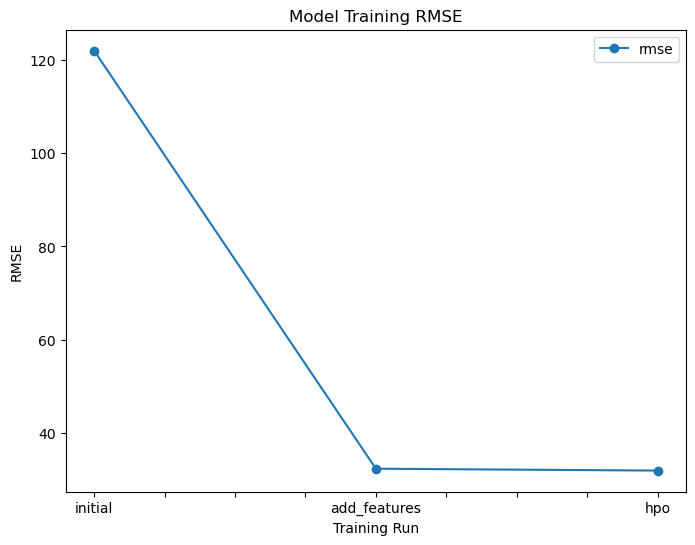

In [9]:
# RMSE of the best model from each training run
fig = pd.DataFrame(
    {
        "train_eval": ["initial", "add_features", "hpo"],
        "rmse": [122.01, 32.34, 31.94]
    }
).plot(
    x="train_eval",
    y="rmse",
    figsize=(8, 6),
    marker="o",
    title="Model Training RMSE", 
    xlabel="Training Run",
    ylabel="RMSE"
).get_figure()

fig.savefig("model_train_score_eh.png")

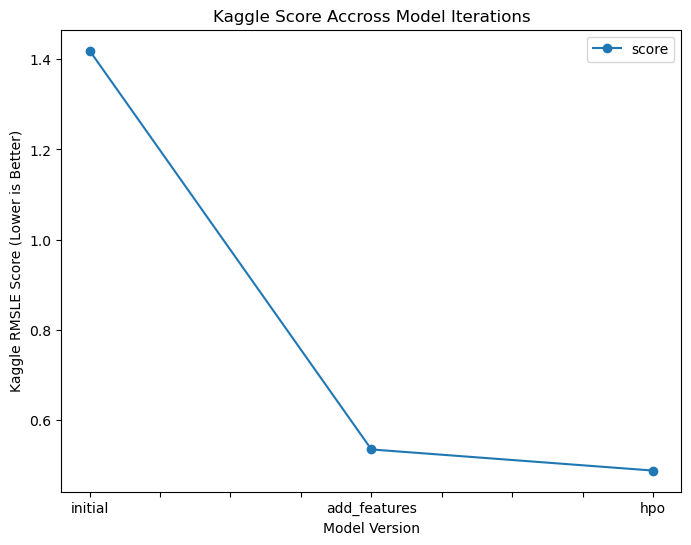

In [10]:
# Take the 3 kaggle scores and creating a line plot to show improvement
fig = pd.DataFrame(
    {
        "test_eval": ["initial", "add_features", "hpo"],
        "score": [1.41883, 0.53507, 0.48823]
    }
).plot(
    x="test_eval", 
    y="score", 
    figsize=(8, 6),
    marker="o",
    title="Kaggle Score Accross Model Iterations", 
    xlabel="Model Version",
    ylabel="Kaggle RMSLE Score (Lower is Better)"
).get_figure()
fig.savefig('model_test_score_eh.png')

### Hyperparameter table

In [60]:
# The 3 hyperparameters we tuned with the kaggle score as the result
pd.DataFrame({
    "model": ["initial", "add_features", "hpo"],
    "hpo1": ["default", "default", "num_bag_folds=5"],
    "hpo2": ["default", "default", "num_stack_levels=1"],
    "hpo3": ["medium_quality", "medium_quality", "good_quality"],
    "score": [1.41883, 0.53507, 0.48823]
})

,model,hpo1,hpo2,hpo3,score
0,initial,default,default,medium_quality,1.41883
1,add_features,default,default,medium_quality,0.53507
2,hpo,num_bag_folds=5,num_stack_levels=1,good_quality,0.48823


In [1]:
!jupyter nbconvert --to html project.ipynb

[NbConvertApp] Converting notebook project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 913080 bytes to project.html
